
Overview: "Short-Term Power Demand Forecasting"

An end-to-end machine learning pipeline designed to forecast national power demand using 10 years of historical grid telemetry, thermodynamic weather data, and macroeconomic indicators. 

The final model (XGBoost) achieved a 2.99% Mean Absolute Percentage Error (MAPE) on a hold-out test set, successfully mapping highly non-linear human energy consumption patterns.

Thermodynamic Accumulation: Engineered a 24-hour temperature lag to capture building "heat soak," allowing the model to understand that sustained heatwaves drive exponential cooling demand.

System Inertia Mapping: Utilized multi-scale historical lags (1h, 24h, 168h) and rolling means to capture the physical, continuous flow of grid electricity.

"Model Performance"

Non-linear ensemble models vastly outperformed linear baselines in capturing summer cooling spikes. 

| Model | Test MAPE | RMSE |
| XGBoost (Selected)| 2.99% | 523.78 |
| LightGBM | 3.00% | 491.13 |
| Random Forest | 3.66% | 570.31 |
| Linear Regression | 5.08% | 714.60 |

->Quick Start

Ensure you have Python 3.8+ installed.

Clone the repository
git clone [https://github.com/yash7090/Predictive_Paradox_IITG_ai.git](https://github.com/yash7090/Predictive_Paradox_IITG_ai.git)

pip install pandas numpy scikit-learn xgboost lightgbm matplotlib seaborn openpyxl time

jupyter notebook

Run pred_para_pipeline_yash.ipynb

Libraries imported successfully.
Data loaded successfully.

Initial Data Sanity & Error Checks
Power Data Rows: 92650
Missing Demand Values: 0 | Impossible Zero/Negative Demand: 0

Weather Data Rows: 107304
Missing Temperatures: 0


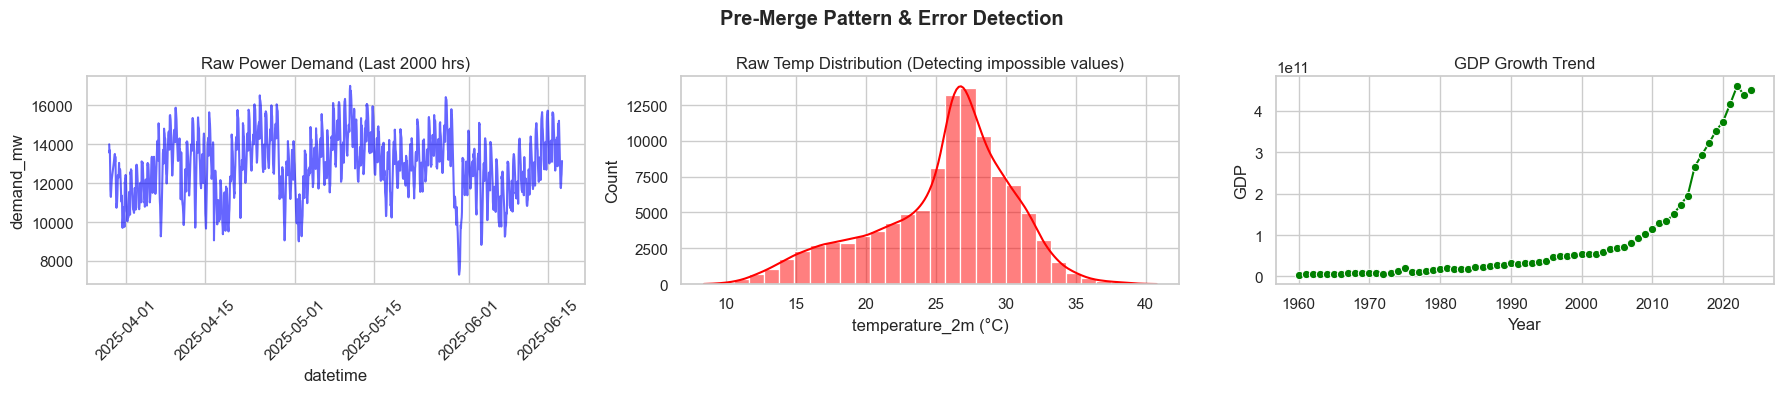

Half-hourly timestamps fixed.
Missing timestamps successfully found and filled using the previous hour.
Data merged successfully and master dataset created.
Extracting time features and applying Year-Month Seasonal IQR
Clean features generated and ready for split
Training Data Rows (<= 2023): 76128
Testing Data Rows (>= 2024): 12804
Feature Relationship


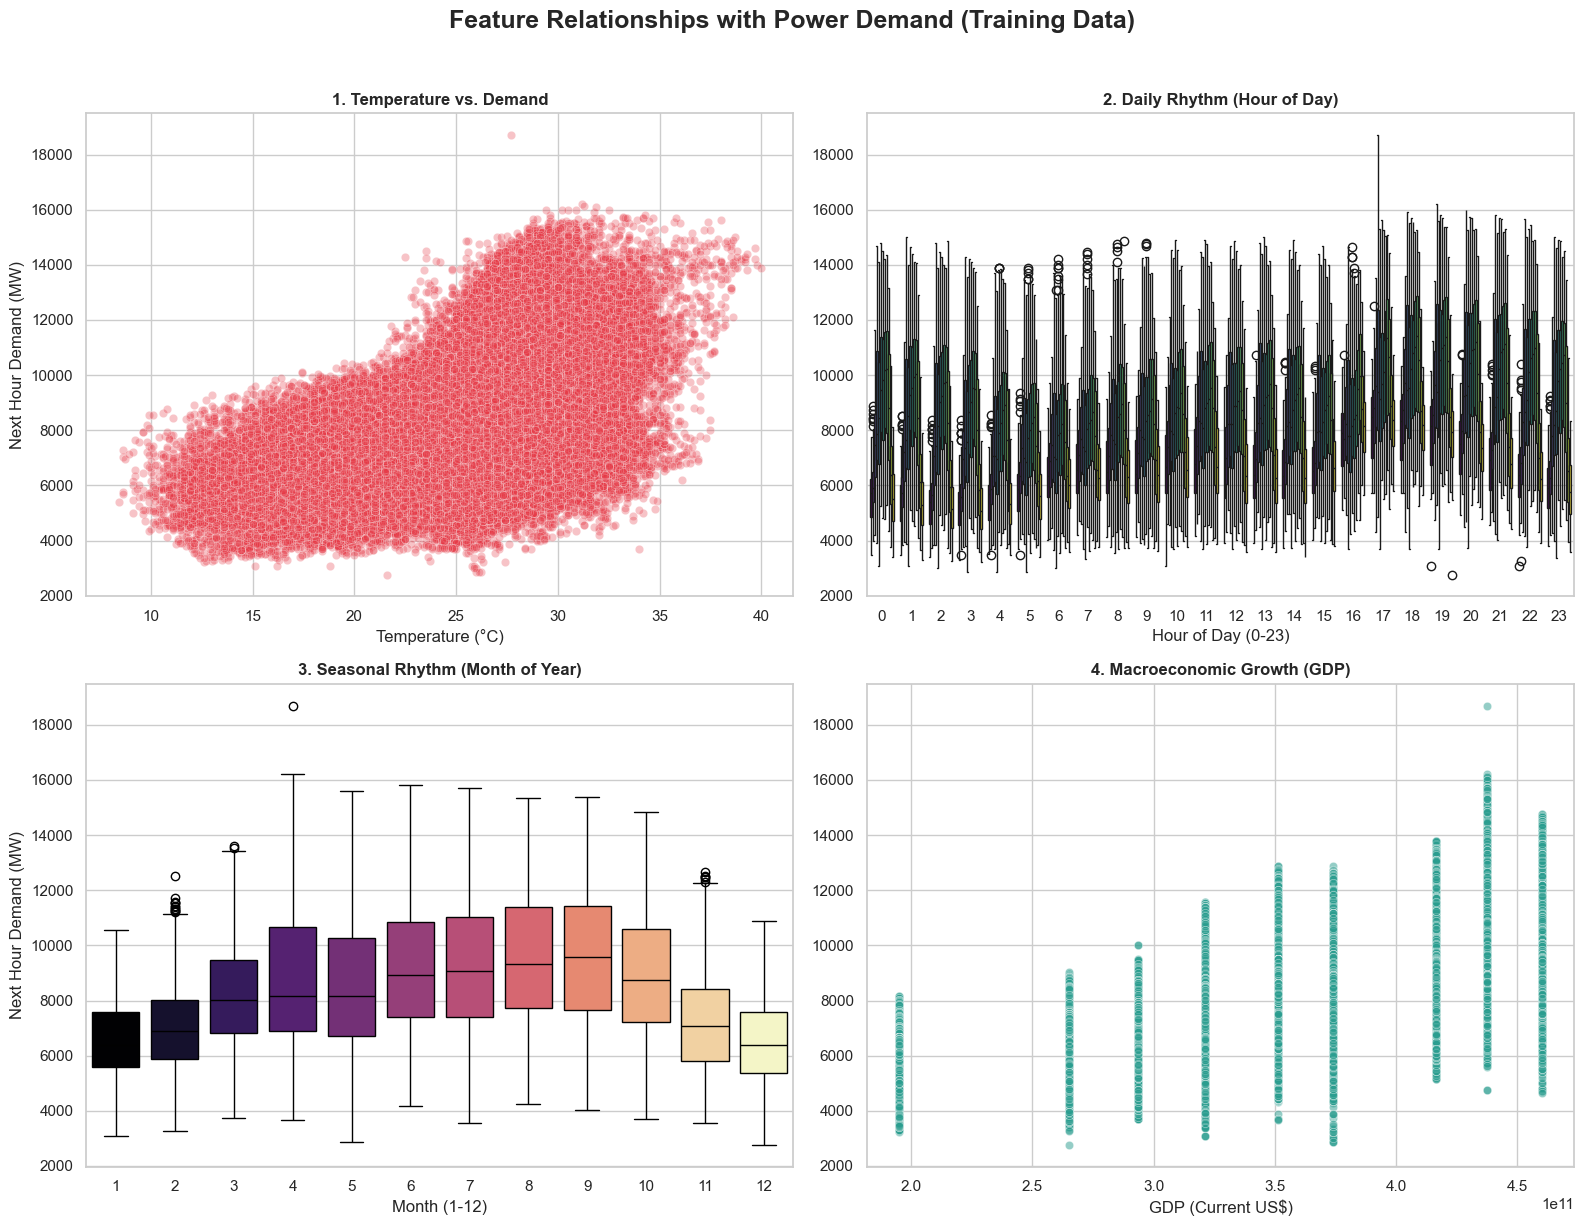

Training all models
Linear Regression    | MAPE:  5.08% | RMSE:  714.59 | Time:  0.1s
Ridge Regression     | MAPE:  5.08% | RMSE:  714.60 | Time:  0.0s
Random Forest        | MAPE:  3.66% | RMSE:  570.31 | Time: 15.7s
LightGBM             | MAPE:  3.00% | RMSE:  491.13 | Time: 12.1s
XGBoost              | MAPE:  2.99% | RMSE:  523.78 | Time:  7.0s

Final Scoreboard:


,Model,Test MAPE (%),Test RMSE,Test MAE,R2 Score,Time (sec)
1,XGBoost,2.99,523.78,344.92,0.950,7.05
2,LightGBM,3.00,491.13,341.92,0.956,12.07
3,Random Forest,3.66,570.31,408.02,0.941,15.70
4,Ridge Regression,5.08,714.60,544.38,0.907,0.04
5,Linear Regression,5.08,714.59,544.38,0.907,0.07


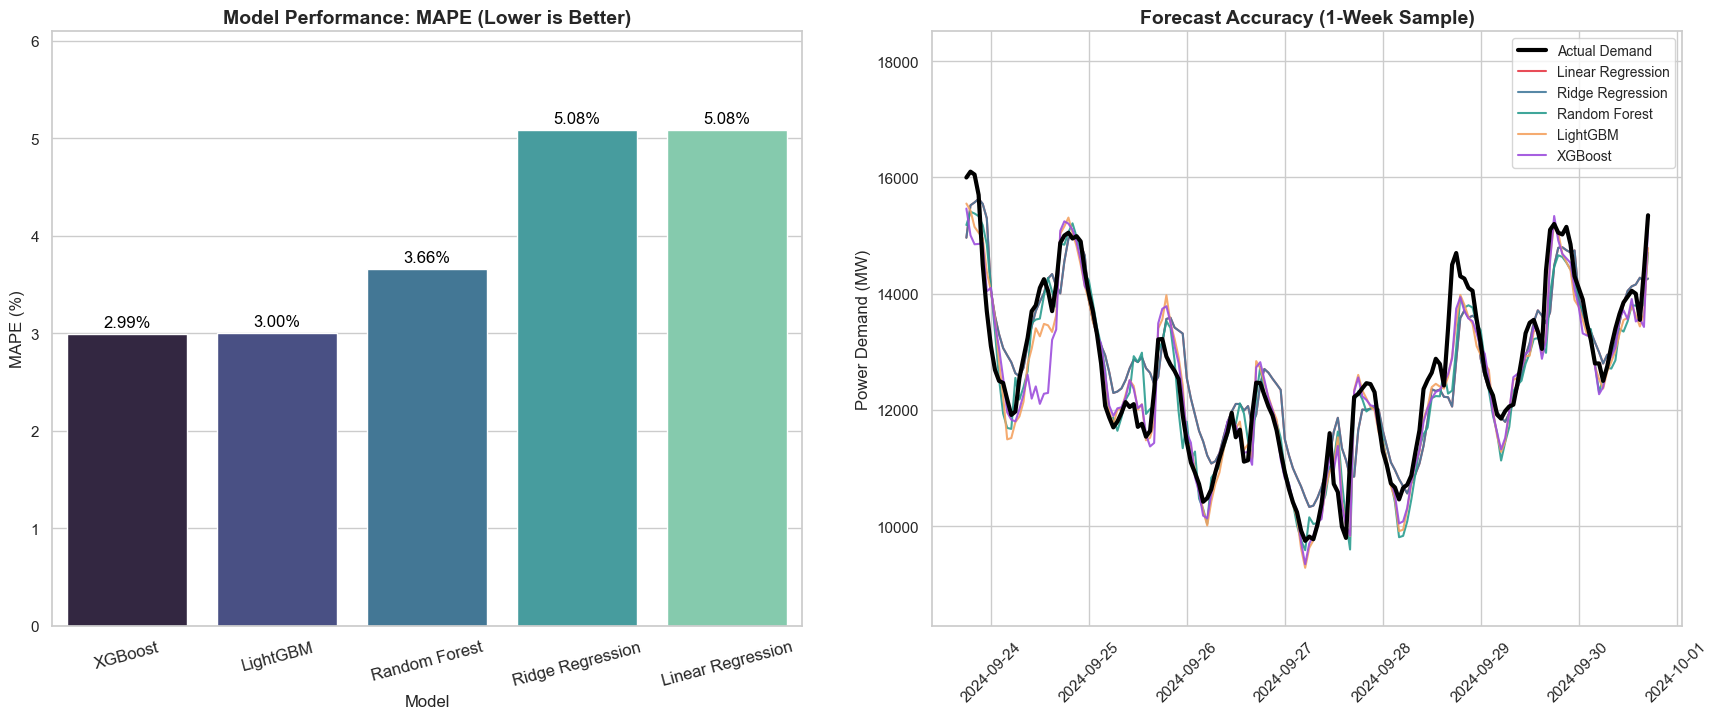

Generating feature importance and diagnostic plots


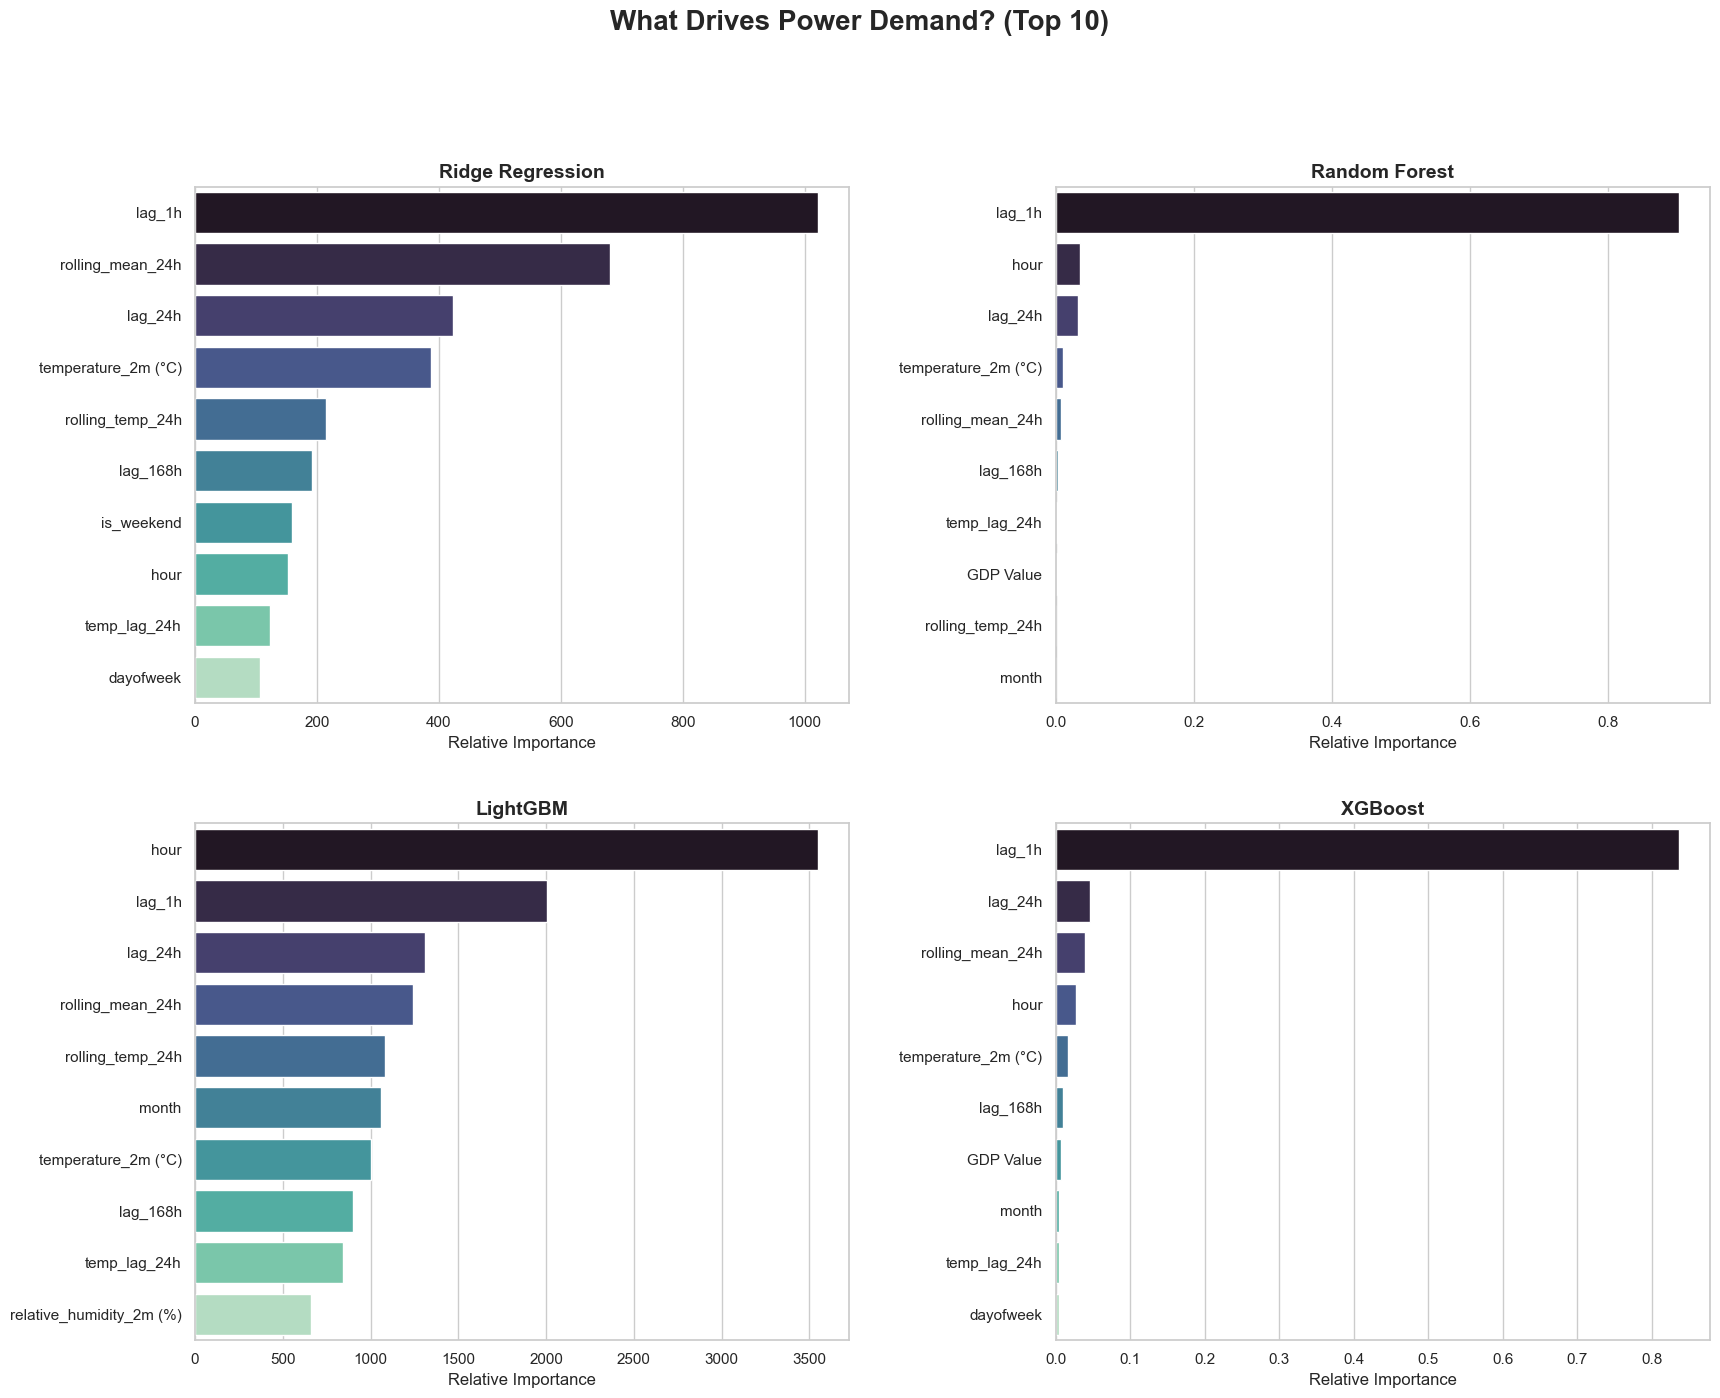

Generating Linear Regression diagnostic plots


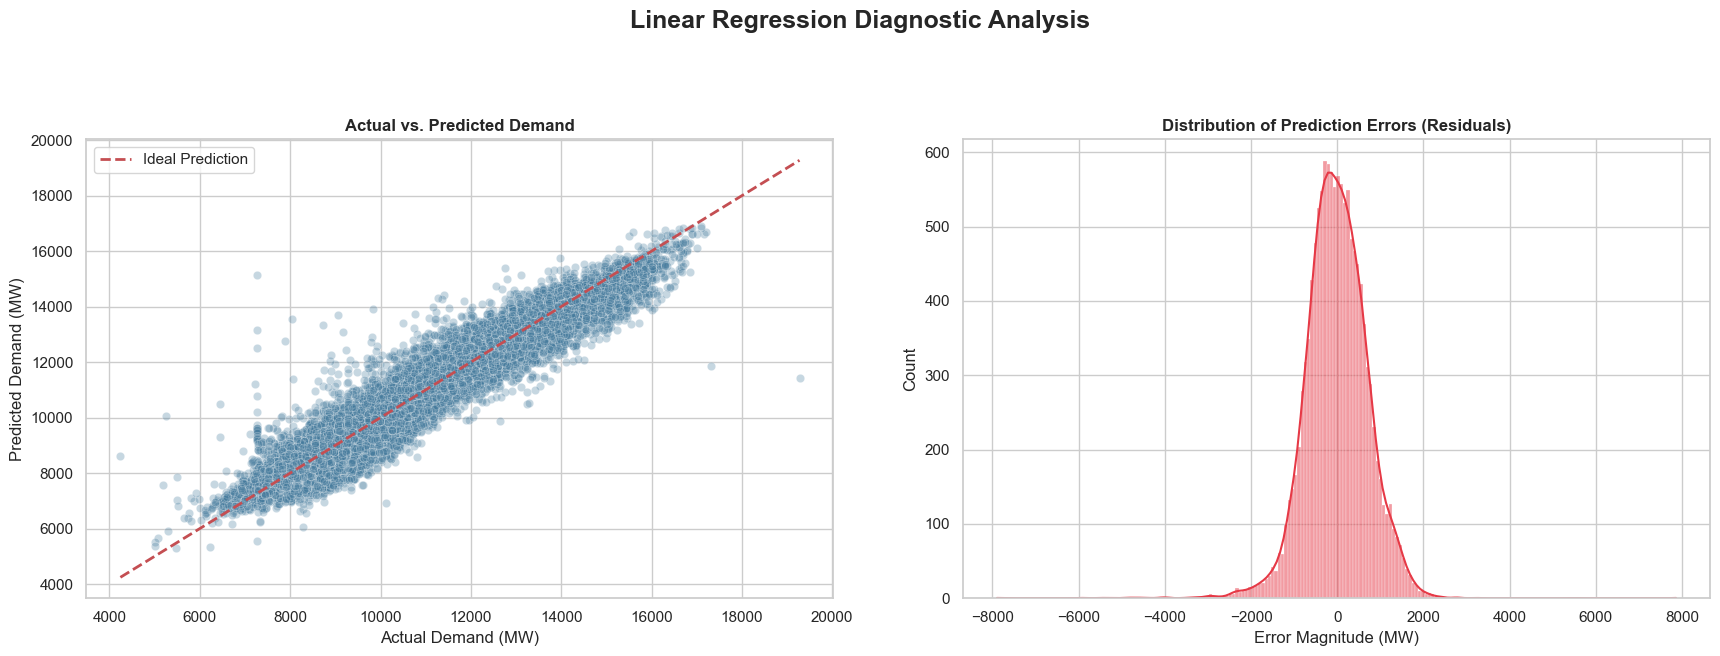

Significant Drivers Across All Datasets (XGBOOST)

-lag_1h                    | Impact:  83.6% | Source: Power Data (Momentum)
-lag_24h                   | Impact:   4.6% | Source: Power Data (Momentum)
-rolling_mean_24h          | Impact:   3.9% | Source: Power Data (Momentum)
-hour                      | Impact:   2.7% | Source: Power Data (Routine)
-temperature_2m (°C)       | Impact:   1.6% | Source: Weather Data
-lag_168h                  | Impact:   1.0% | Source: Power Data (Momentum)

Extreme Events Detected

The biggest drop in demand happened on: 2016-12-09 20:00:00
Demand was repaired to: 2767.5 MW

The biggest spike in demand happened on: 2023-04-18 18:00:00
Demand was capped at: 18694.625 MW


In [12]:
# Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse, r2_score
from sklearn.linear_model import LinearRegression as lr, Ridge
from sklearn.ensemble import RandomForestRegressor as rfg, IsolationForest
import xgboost as xgb
import lightgbm as lgb
import time
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

#Data loading
#Power Data
powdf = pd.read_excel('data/PGCB_date_power_demand.xlsx',
                      parse_dates=['datetime'])

#Economic Data
ecodf = pd.read_csv('data/economic_full_1.csv')

#Weather Data (skipping first 3 rows)
weadf = pd.read_excel('data/weather_data.xlsx',
                      skiprows=3, parse_dates=['time'])

weadf = weadf.rename(columns={'time': 'datetime'})


#Initial EDA and error detection
print("\nInitial Data Sanity & Error Checks")

#Power data errors
print(f"Power Data Rows: {len(powdf)}")
misspow = powdf['demand_mw'].isnull().sum()
powzero = (powdf['demand_mw'] <= 0).sum()
print(
    f"Missing Demand Values: {misspow} | Impossible Zero/Negative Demand: {powzero}")

#Weather data errors
print(f"\nWeather Data Rows: {len(weadf)}")
misstemp = weadf['temperature_2m (°C)'].isnull().sum()
print(f"Missing Temperatures: {misstemp}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Pre-Merge Pattern & Error Detection", fontweight='bold')

#Demand over time (spotting extreme drops/spikes)
sns.lineplot(data=powdf[-2000:], x='datetime',
             y='demand_mw', ax=axes[0], color='blue', alpha=0.6)
axes[0].set_title("Raw Power Demand (Last 2000 hrs)")
axes[0].tick_params(axis='x', rotation=45)

#Temperature Distribution (checking for broken sensors)
sns.histplot(weadf['temperature_2m (°C)'].dropna(),
             bins=30, ax=axes[1], color='red', kde=True)
axes[1].set_title("Raw Temp Distribution (Detecting impossible values)")

#Economic GDP Extraction
gdpcheck = ecodf[ecodf['Indicator Name'] == 'GDP (current US$)'].copy()
gdpcheck = pd.melt(gdpcheck, id_vars=[
                   'Indicator Name'], var_name='Year', value_name='GDP')
gdpcheck['Year'] = pd.to_numeric(gdpcheck['Year'], errors='coerce')
sns.lineplot(data=gdpcheck.dropna(), x='Year', y='GDP',
             ax=axes[2], color='green', marker='o')
axes[2].set_title("GDP Growth Trend")

plt.tight_layout()
plt.show()

#Handling missing data and anomalies
#Handling anomalies
powdf = powdf.drop_duplicates(subset=['datetime'])
powdf['hourly_timestamp'] = powdf['datetime'].dt.floor('h')
powhourdf = powdf.drop(columns=['datetime']).groupby(
    'hourly_timestamp').mean(numeric_only=True).reset_index()
powhourdf = powhourdf.rename(columns={'hourly_timestamp': 'datetime'})


#Handling missing data
starttime = powhourdf['datetime'].min()
endtime = powhourdf['datetime'].max()

fixedtimeline = pd.date_range(start=starttime, end=endtime, freq='h')

powhourdf.set_index('datetime', inplace=True)

powhourdf = powhourdf.reindex(fixedtimeline, method='ffill')

powhourdf = powhourdf.reset_index().rename(columns={'index': 'datetime'})


#Merging all three files

gdpdata = ecodf[ecodf['Indicator Name'] == 'GDP (current US$)'].copy()

id_cols = [col for col in ['Country Name', 'Country Code',
                           'Indicator Name', 'Indicator Code'] if col in gdpdata.columns]
gdpvalue = pd.melt(gdpdata, id_vars=id_cols,
                   var_name='Year', value_name='GDP Value')

gdpvalue['Year'] = gdpvalue['Year'].astype(str).str.extract(r'(\d{4})')
gdpvalue['Year'] = pd.to_numeric(gdpvalue['Year'], errors='coerce')
gdpvalue = gdpvalue.dropna(subset=['Year'])

powhourdf['Year'] = powhourdf['datetime'].dt.year

finaldf = pd.merge(powhourdf, weadf, on='datetime', how='left')
finaldf = pd.merge(
    finaldf, gdpvalue[['Year', 'GDP Value']], on='Year', how='left')

finaldf['GDP Value'] = finaldf['GDP Value'].ffill().bfill()
finaldf = finaldf.sort_values('datetime')


#Feature engineering and outlier handling

#Temporal features
finaldf['hour'] = finaldf['datetime'].dt.hour
finaldf['dayofweek'] = finaldf['datetime'].dt.dayofweek
finaldf['month'] = finaldf['datetime'].dt.month
finaldf['is_weekend'] = finaldf['dayofweek'].isin([5, 6]).astype(int)

#Seasonal IQR Smoothening

def seasonSmoothing(group):
    Q1, Q3 = group.quantile(0.25), group.quantile(0.75)
    IQR = Q3 - Q1
    return group.clip(lower=max(0, Q1 - 1.5 * IQR), upper=Q3 + 1.5 * IQR)


finaldf['demand_mw'] = finaldf.groupby(['Year', 'month'])[
    'demand_mw'].transform(seasonSmoothing)

#Feature engineering
finaldf['lag_1h'] = finaldf['demand_mw'].shift(1)
finaldf['lag_24h'] = finaldf['demand_mw'].shift(24)
finaldf['lag_168h'] = finaldf['demand_mw'].shift(168)
finaldf['rolling_mean_24h'] = finaldf['demand_mw'].rolling(window=24).mean()

finaldf['temp_lag_24h'] = finaldf['temperature_2m (°C)'].shift(24)
finaldf['rolling_temp_24h'] = finaldf['temperature_2m (°C)'].rolling(
    window=24).mean()

finaldf['target_next_hour'] = finaldf['demand_mw'].shift(-1)

finaldf = finaldf.dropna(
    subset=['target_next_hour', 'lag_168h', 'temp_lag_24h', 'temperature_2m (°C)'])

#Train-Test Split (upto 2023 and 2024)

features = [
    'hour', 'dayofweek', 'month', 'is_weekend',
    'lag_1h', 'lag_24h', 'lag_168h', 'rolling_mean_24h',
    'temperature_2m (°C)', 'temp_lag_24h', 'rolling_temp_24h',
    'relative_humidity_2m (%)', 'GDP Value'
]


finaldf = finaldf.sort_values('datetime')

#Year-based split
trainData = finaldf[finaldf['Year'] <= 2023].copy()
testData = finaldf[finaldf['Year'] >= 2024].copy()

x_train, y_train = trainData[features], trainData['target_next_hour']
x_test, y_test = testData[features], testData['target_next_hour']

print(f"Training Data Rows (<= 2023): {len(x_train)}")
print(f"Testing Data Rows (>= 2024): {len(x_test)}")

# EDA
print("Feature Relationship")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Feature Relationships with Power Demand (Training Data)',
             fontsize=18, fontweight='bold', y=1.02)

#Temperature vs Demand (Scatter Plot)
sns.scatterplot(data=trainData, x='temperature_2m (°C)', y='target_next_hour',
                alpha=0.3, color='#e63946', ax=axes[0, 0])
axes[0, 0].set_title('1. Temperature vs. Demand', fontweight='bold')
axes[0, 0].set_ylabel('Next Hour Demand (MW)')
axes[0, 0].set_xlabel('Temperature (°C)')

#Hour of Day vs Demand (Box Plot)
sns.boxplot(data=trainData, x='hour', y='target_next_hour',
            hue='month', legend=False, palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title('2. Daily Rhythm (Hour of Day)', fontweight='bold')
axes[0, 1].set_ylabel('')
axes[0, 1].set_xlabel('Hour of Day (0-23)')

#Month vs Demand (Box Plot)
sns.boxplot(data=trainData, x='month', y='target_next_hour',
            hue='month', legend=False, palette='magma', ax=axes[1, 0])
axes[1, 0].set_title('3. Seasonal Rhythm (Month of Year)', fontweight='bold')
axes[1, 0].set_ylabel('Next Hour Demand (MW)')
axes[1, 0].set_xlabel('Month (1-12)')

#GDP vs Demand (Scatter Plot)
sns.scatterplot(data=trainData, x='GDP Value', y='target_next_hour',
                alpha=0.5, color='#2a9d8f', ax=axes[1, 1])
axes[1, 1].set_title('4. Macroeconomic Growth (GDP)', fontweight='bold')
axes[1, 1].set_ylabel('')
axes[1, 1].set_xlabel('GDP (Current US$)')

plt.tight_layout()
plt.show()

#Model Training

#Scaling gdp and month
scaler = StandardScaler()
x_trainScaled = pd.DataFrame(scaler.fit_transform(
    x_train), columns=x_train.columns, index=x_train.index)
x_testScaled = pd.DataFrame(scaler.transform(
    x_test), columns=x_test.columns, index=x_test.index)

models = {
    "Linear Regression": lr(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": rfg(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42),
    "LightGBM": lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, verbose=-1),
    "XGBoost": xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, n_jobs=-1, random_state=42)
}

results = []
trModels = {}

print("Training all models")
for name, model in models.items():
    starttime = time.time()

    model.fit(x_trainScaled, y_train)
    trModels[name] = model

    preds = model.predict(x_testScaled)

    mape = np.mean(np.abs((y_test - preds) / (y_test + 1e-10))) * 100
    rmse_val = np.sqrt(mse(y_test, preds))
    mae_val = mae(y_test, preds)
    r2_val = r2_score(y_test, preds)

    traintime = time.time() - starttime

    results.append({
        "Model": name,
        "Test MAPE (%)": round(mape, 2),
        "Test RMSE": round(rmse_val, 2),
        "Test MAE": round(mae_val, 2),
        "R2 Score": round(r2_val, 3),
        "Time (sec)": round(traintime, 2)
    })
    print(f"{name: <20} | MAPE: {mape:>5.2f}% | RMSE: {rmse_val:>7.2f} | Time: {traintime:>4.1f}s")

#Scoreboard and model comparison
resultsdf = pd.DataFrame(results).sort_values(
    by="Test MAPE (%)").reset_index(drop=True)
resultsdf.index = resultsdf.index + 1
print("\nFinal Scorea:")
display(resultsdf)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

#MAPE Bar Chart
sns.barplot(data=resultsdf, x='Model', y='Test MAPE (%)',
            hue='Model', legend=False, palette='mako', ax=axes[0])
axes[0].set_title('Model Performance: MAPE (Lower is Better)',
                  fontweight='bold', fontsize=14)
axes[0].set_ylabel('MAPE (%)', fontsize=12)
axes[0].set_ylim(0, resultsdf['Test MAPE (%)'].max() * 1.2)
axes[0].tick_params(axis='x', rotation=15, labelsize=12)

for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.2f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='baseline', color='black', xytext=(0, 5),
                     textcoords='offset points', fontsize=12)

#1 Week Forecast Prediction
start_i = len(x_testScaled) // 2
end_i = start_i + 168

plotx = x_testScaled.iloc[start_i:end_i]
ploty = y_test.iloc[start_i:end_i]
plotdates = testData['datetime'].iloc[start_i:
                                       end_i] if 'datetime' in testData.columns else testData.index[start_i:end_i]

axes[1].plot(plotdates, ploty.values, label='Actual Demand',
             color='black', linewidth=3, zorder=5)

colors = ['#e63946', '#457b9d', '#2a9d8f', '#f4a261', '#9d4edd']
for (name, model), color in zip(trModels.items(), colors):
    slice_preds = model.predict(plotx)
    axes[1].plot(plotdates, slice_preds,
                 label=f'{name}', color=color, linewidth=1.5, alpha=0.9)

axes[1].set_title('Forecast Accuracy (1-Week Sample)',
                  fontweight='bold', fontsize=14)
axes[1].set_ylabel('Power Demand (MW)', fontsize=12)

axes[1].set_ylim(ploty.min() * 0.85, ploty.max() * 1.15)

axes[1].legend(loc='upper right', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)


plt.tight_layout(pad=3.0)
plt.show()

print(f"Feature importance and diagnostic plots")


plotmodels = ["Ridge Regression", "Random Forest", "LightGBM", "XGBoost"]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('What Drives Power Demand? (Top 10)',
             fontsize=20, fontweight='bold', y=1.02)
axes = axes.flatten()

for idx, name in enumerate(plotmodels):
    model = trModels[name]

    if "Regression" in name:
        importances = np.abs(model.coef_)
    else:
        importances = model.feature_importances_

    importancedf = pd.DataFrame({
        'Feature': features,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False).head(10)

    sns.barplot(data=importancedf, x='Importance', y='Feature',
                hue='Feature', palette='mako', legend=False, ax=axes[idx])
    axes[idx].set_title(f'{name}', fontweight='bold', fontsize=14)
    axes[idx].set_xlabel('Relative Importance')
    axes[idx].set_ylabel('')

plt.tight_layout(pad=3.0)
plt.show()



#Linear regression plot
print(f"Linear Regression")

lrModel = trModels["Linear Regression"]


lrPreds = lrModel.predict(x_testScaled)
residuals = y_test - lrPreds

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Linear Regression Diagnostic Analysis',
             fontsize=18, fontweight='bold')


sns.scatterplot(x=y_test, y=lrPreds, alpha=0.3, ax=axes[0], color='#457b9d')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(),
             y_test.max()], '--r', linewidth=2, label='Ideal Prediction')
axes[0].set_title('Actual vs. Predicted Demand', fontweight='bold')
axes[0].set_xlabel('Actual Demand (MW)')
axes[0].set_ylabel('Predicted Demand (MW)')
axes[0].legend()


sns.histplot(residuals, kde=True, ax=axes[1], color='#e63946')
axes[1].set_title(
    'Distribution of Prediction Errors (Residuals)', fontweight='bold')
axes[1].set_xlabel('Error Magnitude (MW)')

plt.tight_layout(pad=3.0)
plt.show()

print("Significant drivers for xgboost ")
print("")

xgbModel = trModels["XGBoost"]
xgbimportancedf = pd.DataFrame({
    'Feature': features,
    'Gain_Score': xgbModel.feature_importances_
})

xgbimportancedf['Impact (%)'] = (
    xgbimportancedf['Gain_Score'] / xgbimportancedf['Gain_Score'].sum()) * 100
significantfeatures = xgbimportancedf[xgbimportancedf['Impact (%)'] > 1.0].sort_values(
    by='Impact (%)', ascending=False)

for index, row in significantfeatures.iterrows():
    source = "Power Data (Momentum)" if "lag" in row['Feature'] or "rolling" in row['Feature'] else \
             "Power Data (Routine)" if row['Feature'] in ['hour', 'dayofweek', 'month', 'is_weekend'] else \
             "Weather Data" if "temp" in row['Feature'] or "humidity" in row['Feature'] else \
             "Economic Data" if "GDP" in row['Feature'] else "Anomaly Data"

    print(
        f"-{row['Feature']: <25} | Impact: {row['Impact (%)']:>5.1f}% | Source: {source}")

print("")



print("Extreme Events")
print("")

lowestday = trainData.loc[trainData['demand_mw'].idxmin()]
print(f"The biggest drop in demand happened on: {lowestday['datetime']}")
print(f"Demand was repaired to: {lowestday['demand_mw']} MW")

print("")
highestday = trainData.loc[trainData['demand_mw'].idxmax()]
print(f"The biggest spike in demand happened on: {highestday['datetime']}")
print(f"Demand was capped at: {highestday['demand_mw']} MW")
